In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("kidney_disease.csv")

In [3]:
df.head(10)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [4]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [5]:
df.drop(columns=["id"],inplace= True)

In [6]:
df.columns


Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [8]:
for col in ['wc', 'rc', 'pcv']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [10]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
numerical_cols = [col for col in df.columns if df[col].dtype != 'object']

In [11]:
df[numerical_cols].isnull().sum().sort_values(ascending=False)

rc      131
wc      106
pot      88
sod      87
pcv      71
hemo     52
su       49
sg       47
al       46
bgr      44
bu       19
sc       17
bp       12
age       9
dtype: int64

In [12]:
df[categorical_cols].isnull().sum().sort_values(ascending=False)

rbc               152
pc                 65
pcc                 4
ba                  4
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [13]:
# two method
# radom sampling->higer null value
# mean/mode-> lower null value
def random_sampling(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample

def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [14]:
# appling random sampling in numerical columns
for col in numerical_cols:
    random_sampling(col)
# appling random sampling in categorial columns
random_sampling('rbc')
random_sampling('pc')
for col in categorical_cols:
    impute_mode(col)

In [15]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [16]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,131.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,5.7,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [17]:
# Check for unique values in categorical columns to identify inconsistencies
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()}")

rbc unique values: ['normal' 'abnormal']
pc unique values: ['normal' 'abnormal']
pcc unique values: ['notpresent' 'present']
ba unique values: ['notpresent' 'present']
htn unique values: ['yes' 'no']
dm unique values: ['yes' 'no' ' yes' '\tno' '\tyes']
cad unique values: ['no' 'yes' '\tno']
appet unique values: ['good' 'poor']
pe unique values: ['no' 'yes']
ane unique values: ['no' 'yes']
classification unique values: ['ckd' 'ckd\t' 'notckd']


In [18]:
# Strip leading/trailing spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [19]:
# Check for unique values in categorical columns to identify inconsistencies
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()}")

rbc unique values: ['normal' 'abnormal']
pc unique values: ['normal' 'abnormal']
pcc unique values: ['notpresent' 'present']
ba unique values: ['notpresent' 'present']
htn unique values: ['yes' 'no']
dm unique values: ['yes' 'no']
cad unique values: ['no' 'yes']
appet unique values: ['good' 'poor']
pe unique values: ['no' 'yes']
ane unique values: ['no' 'yes']
classification unique values: ['ckd' 'notckd']


In [20]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

# ploting graph

C:\Users\91824\AppData\Local\Temp\ipykernel_11836\4033873269.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='Set2', order=df[column].value_counts().index[:10])  # Limit to top 10 categories
C:\Users\91824\AppData\Local\Temp\ipykernel_11836\4033873269.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='Set2', order=df[column].value_counts().index[:10])  # Limit to top 10 categories
C:\Users\91824\AppData\Local\Temp\ipykernel_11836\4033873269.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.c

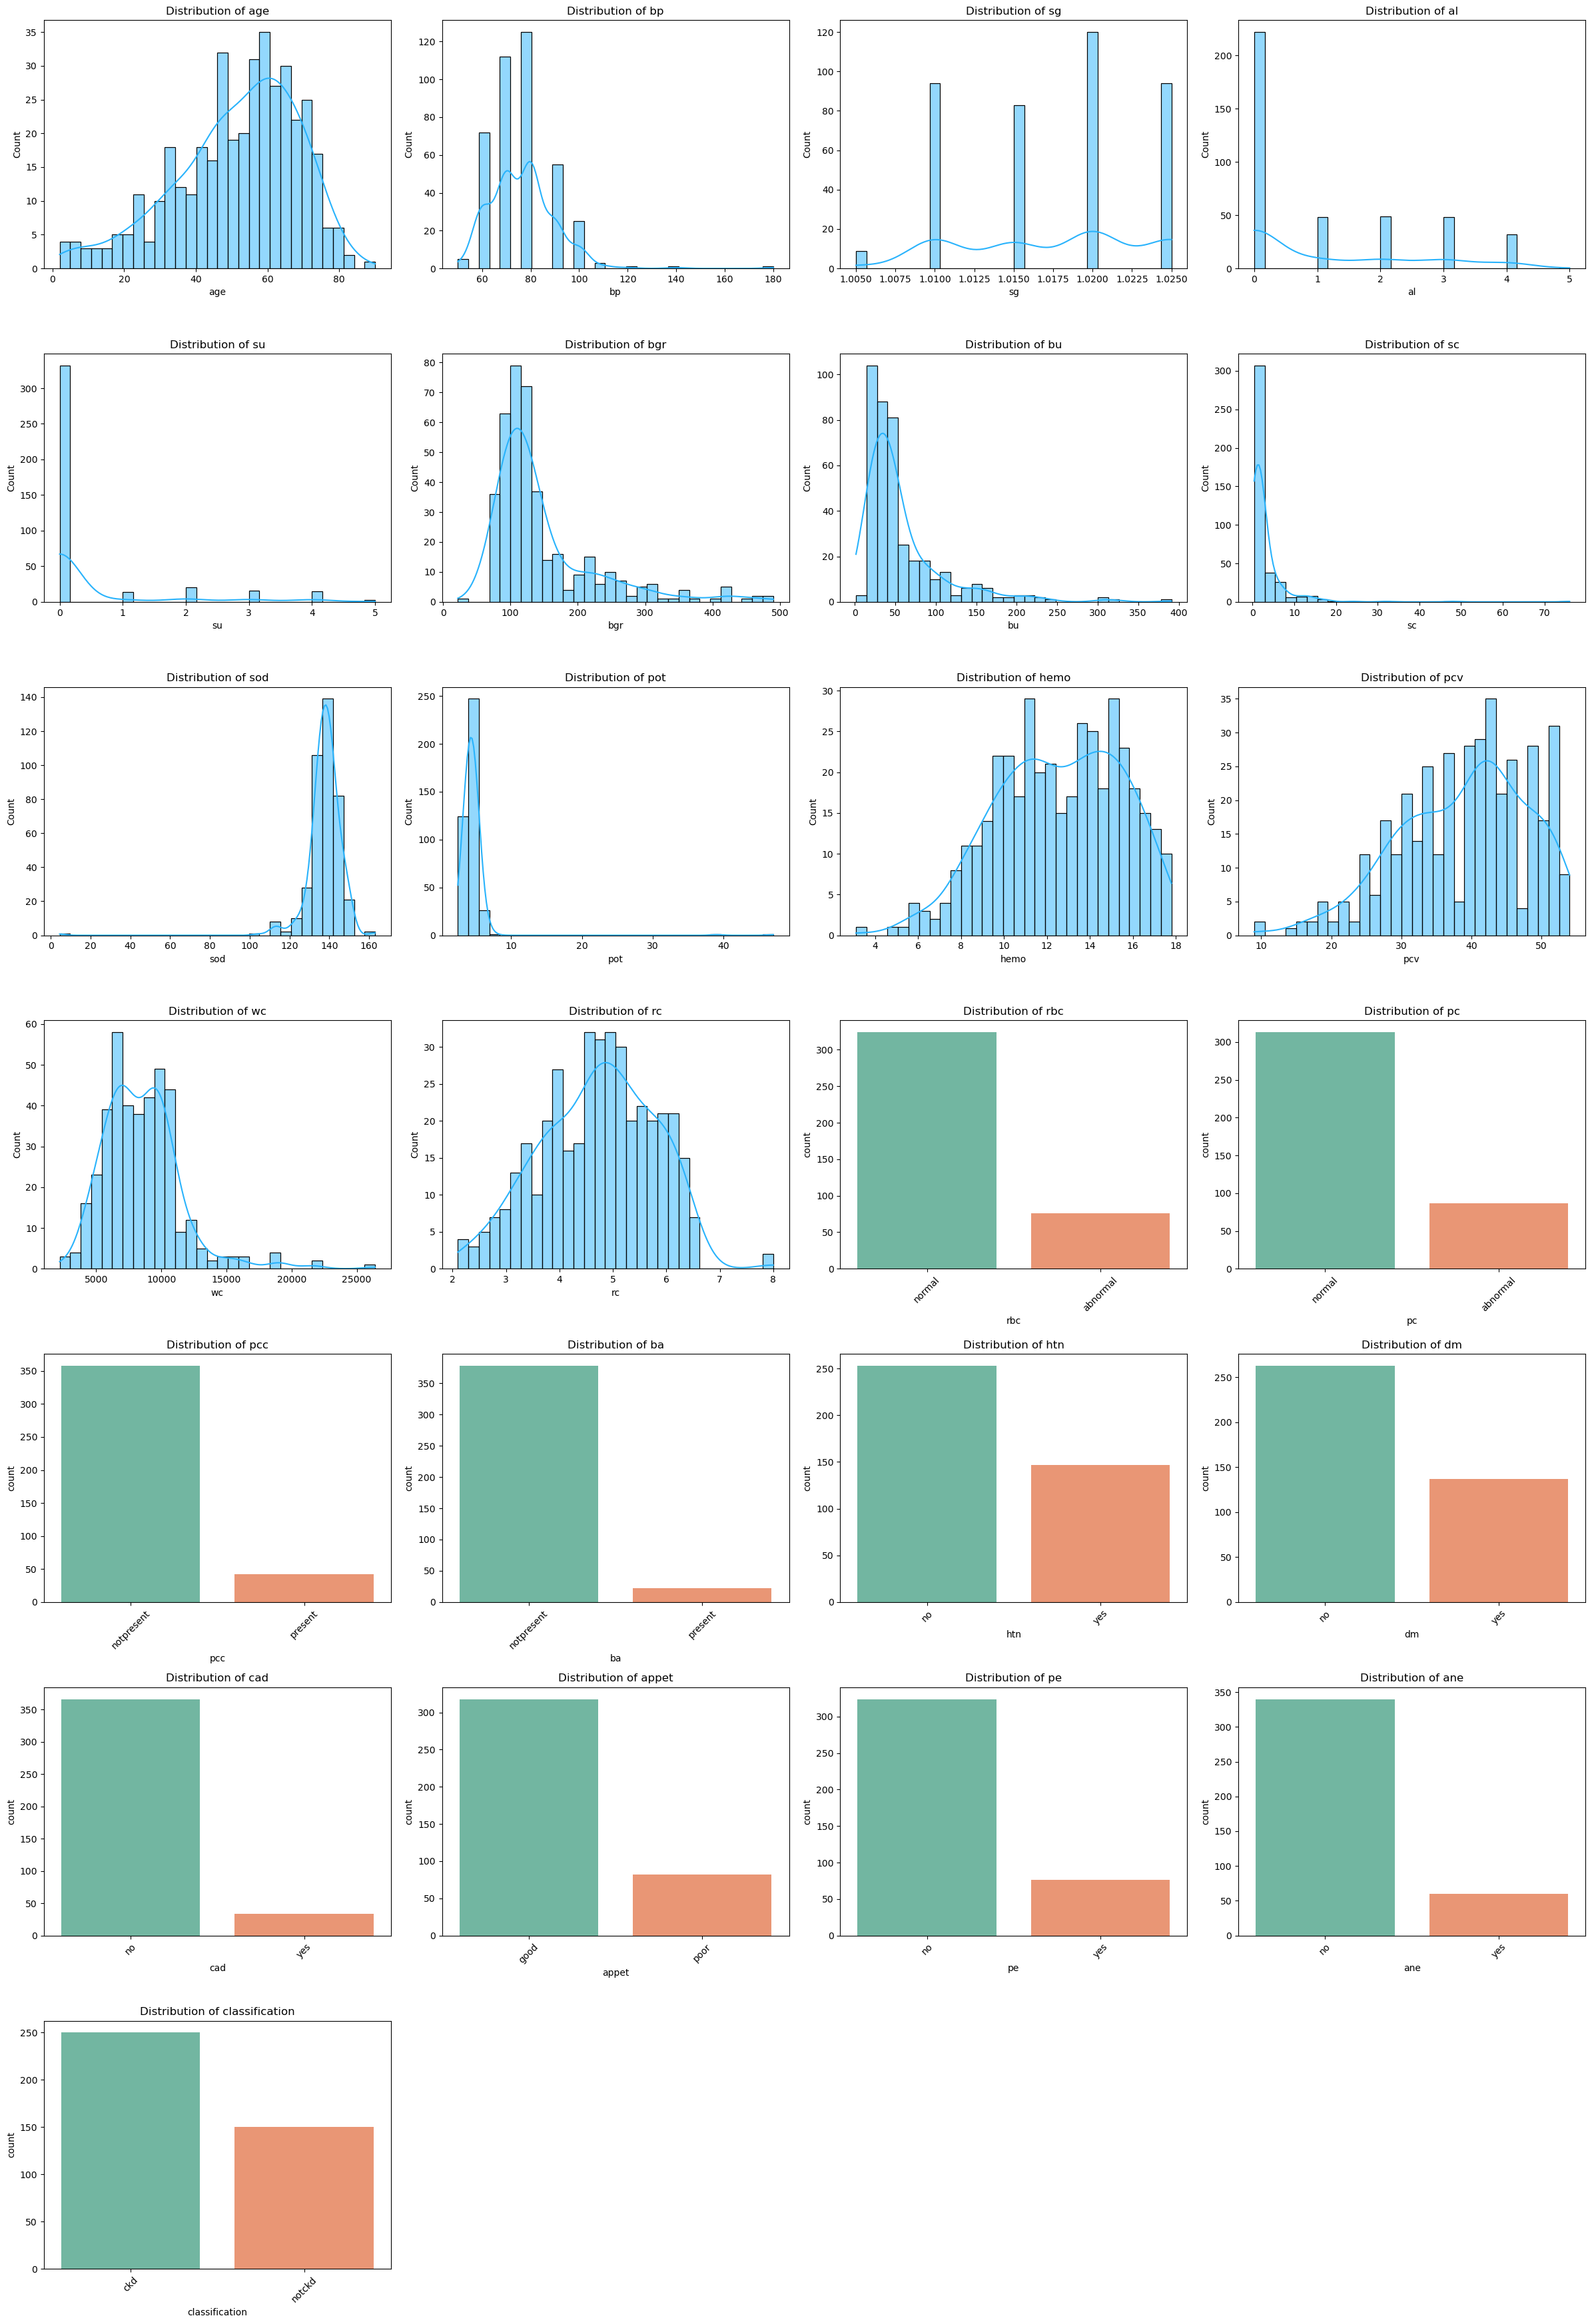

In [21]:
import math

all_cols = numerical_cols + categorical_cols
n_cols = 4
n_rows = math.ceil(len(all_cols) / n_cols)
plt.figure(figsize=(24, 5 * n_rows))  # Adjust height based on rows

# Plot each column
for i, column in enumerate(all_cols, 1):
    ax = plt.subplot(n_rows, n_cols, i)
    if column in numerical_cols:
        sns.histplot(df[column].dropna(), kde=True, bins=30, color='#29b3fc')
    else:
        sns.countplot(x=df[column], palette='Set2', order=df[column].value_counts().index[:10])  # Limit to top 10 categories
        plt.xticks(rotation=45)  # Rotate labels for readability
    plt.xlabel(column)
    plt.title(f"Distribution of {column}")
plt.tight_layout()

In [22]:
from sklearn.preprocessing import LabelEncoder
# Binary categorical columns
binary_cols = ['pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane','rbc','pc','classification']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,131.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,5.7,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int32  
 6   pc              400 non-null    int32  
 7   pcc             400 non-null    int32  
 8   ba              400 non-null    int32  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

# Train test Split

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('classification', axis=1)
y = df['classification']

# Train-test split before scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and fit the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train.isnull().sum()

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wc       0
rc       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
dtype: int64

# Model traing

In [27]:
from sklearn.metrics import classification_report,confusion_matrix,mean_absolute_error

## KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.66      0.62      0.64        50
           1       0.42      0.47      0.44        30

    accuracy                           0.56        80
   macro avg       0.54      0.54      0.54        80
weighted avg       0.57      0.56      0.57        80



array([[31, 19],
       [16, 14]], dtype=int64)

## Random forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



array([[50,  0],
       [ 1, 29]], dtype=int64)

## Logistic regreesion

In [30]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        50
           1       0.85      0.73      0.79        30

    accuracy                           0.85        80
   macro avg       0.85      0.83      0.84        80
weighted avg       0.85      0.85      0.85        80



C:\Users\91824\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
import pickle
with open('logistic_regression.pkl', 'wb') as file:
    pickle.dump(log_reg, file)
print("Model saved successfully as 'logistic_regression.pkl'")

Model saved successfully as 'logistic_regression.pkl'


## Decison tree

In [32]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



array([[50,  0],
       [ 2, 28]], dtype=int64)

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [34]:
y_pred = grid.predict(X_test)
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



array([[50,  0],
       [ 0, 30]], dtype=int64)

In [35]:
import pickle
with open('Decision_tree.pkl', 'wb') as file:
    pickle.dump(grid, file)
print("Model saved successfully as 'Decision_tree.pkl'")

Model saved successfully as 'Decision_tree.pkl'


## Xg Boost|

In [48]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Define XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    scale_pos_weight=1.85,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Apply SMOTE to training data
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Fit the model
xgb.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred = xgb.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



C:\Users\91824\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:41:58] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([[50,  0],
       [ 1, 29]], dtype=int64)

In [47]:
import pickle
with open('Xg_boost_1.pkl', 'wb') as file:
    pickle.dump(xgb, file)
print("Model saved successfully as 'XgBoost_1.pkl'")

Model saved successfully as 'XgBoost_1.pkl'


## Gradiant boosting

In [37]:
#Gradiant Boosting
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

PARAMETERS = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate':[0.001, 0.1, 1, 10],
    'n_estimators':[100,150,180, 200]
}
grid_search_gbc = GridSearchCV(gbc, PARAMETERS, cv=5, n_jobs=-1, verbose= 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.1, 1, 10],
                         'loss': ['log_loss', 'exponential'],
                         'n_estimators': [100, 150, 180, 200]},
             verbose=1)

In [38]:
gbc = GradientBoostingClassifier(learning_rate= 0.1, loss = 'log_loss', n_estimators = 100)
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

In [39]:
y_pred = gbc.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



array([[50,  0],
       [ 2, 28]], dtype=int64)

C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


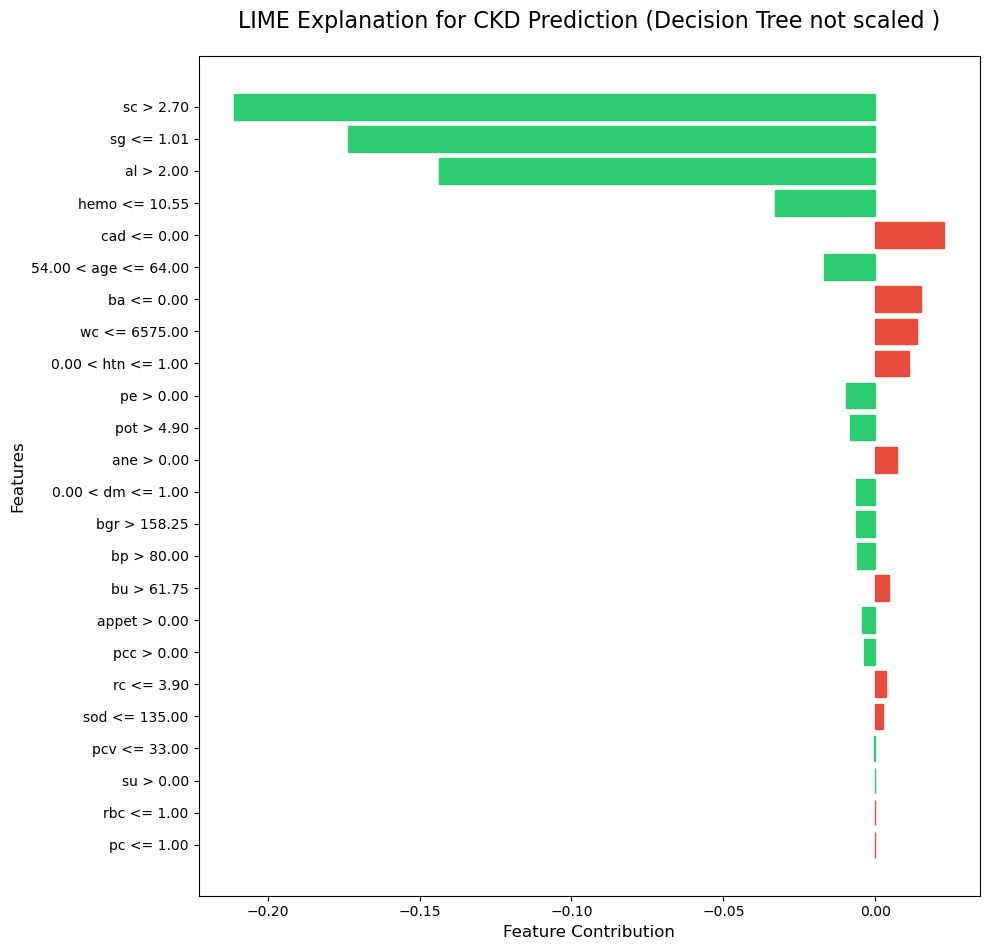

In [40]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split

with open('Decision_tree.pkl', 'rb') as f:
    dt = pickle.load(f)

X_df = X.copy() 
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)
feature_names = X.columns.tolist()
i = 5
instance = X_test_df.iloc[i].values 

# === Initialize LIME explainer ===
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['Not CKD', 'CKD'],
    mode='classification',
    discretize_continuous=True,
)

# === Generate LIME explanation ===
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=dt.predict_proba,
    num_features=len(feature_names)
)

# === Create LIME plot ===
fig = exp.as_pyplot_figure()

# === Customize the plot ===
plt.title("LIME Explanation for CKD Prediction (Decision Tree not scaled )", fontsize=16, pad=20)
plt.xlabel("Feature Contribution", fontsize=12)
plt.ylabel("Features", fontsize=12)

# === Adjust bar colors (green for +, red for -) ===
bars = plt.gca().patches  # Get bar objects
for bar in bars:
    if bar.get_width() >= 0:
        bar.set_color('#e74c3c')  # Green
    else:
        bar.set_color('#2ecc71')  # Red

# === Improve layout ===
plt.tick_params(axis='y', labelsize=10)
plt.tick_params(axis='x', labelsize=10)
fig.set_size_inches(10, max(6, len(feature_names) * 0.4))
plt.subplots_adjust(left=0.3)
plt.tight_layout()


C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


LIME plot saved: lime_plots/lime_sample_0.png


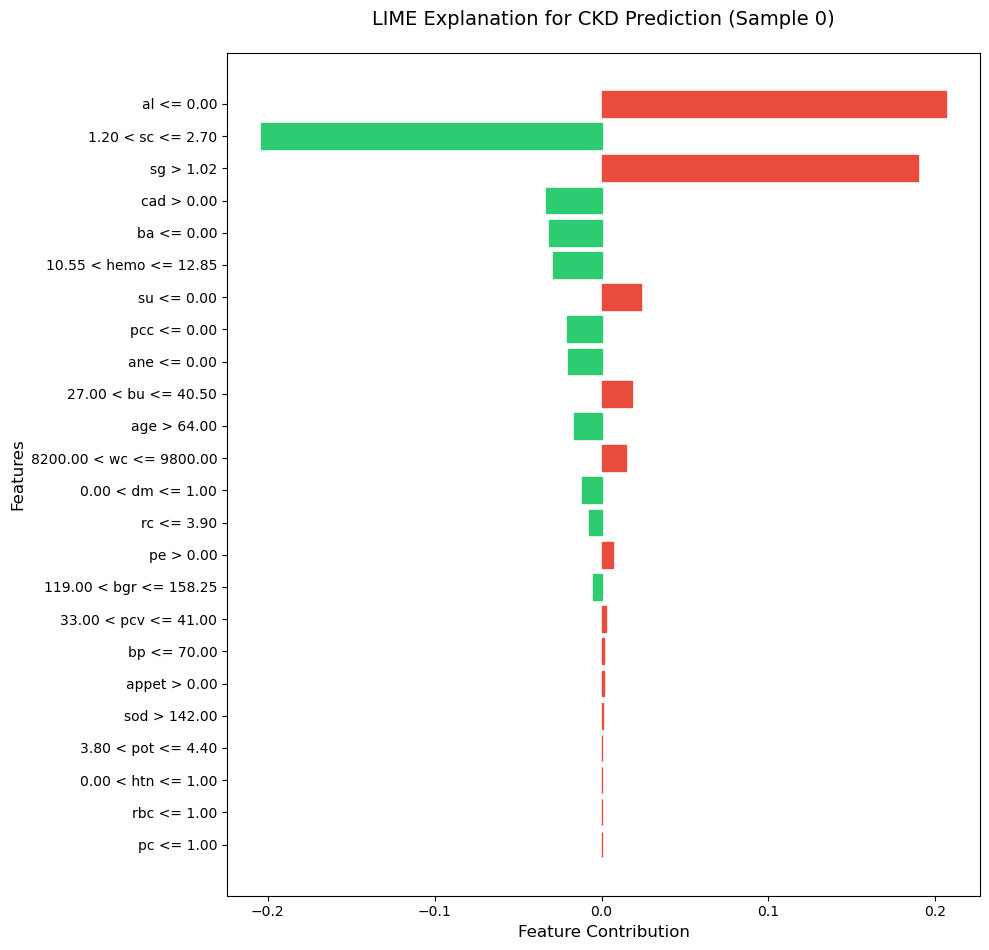

C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


LIME plot saved: lime_plots/lime_sample_1.png


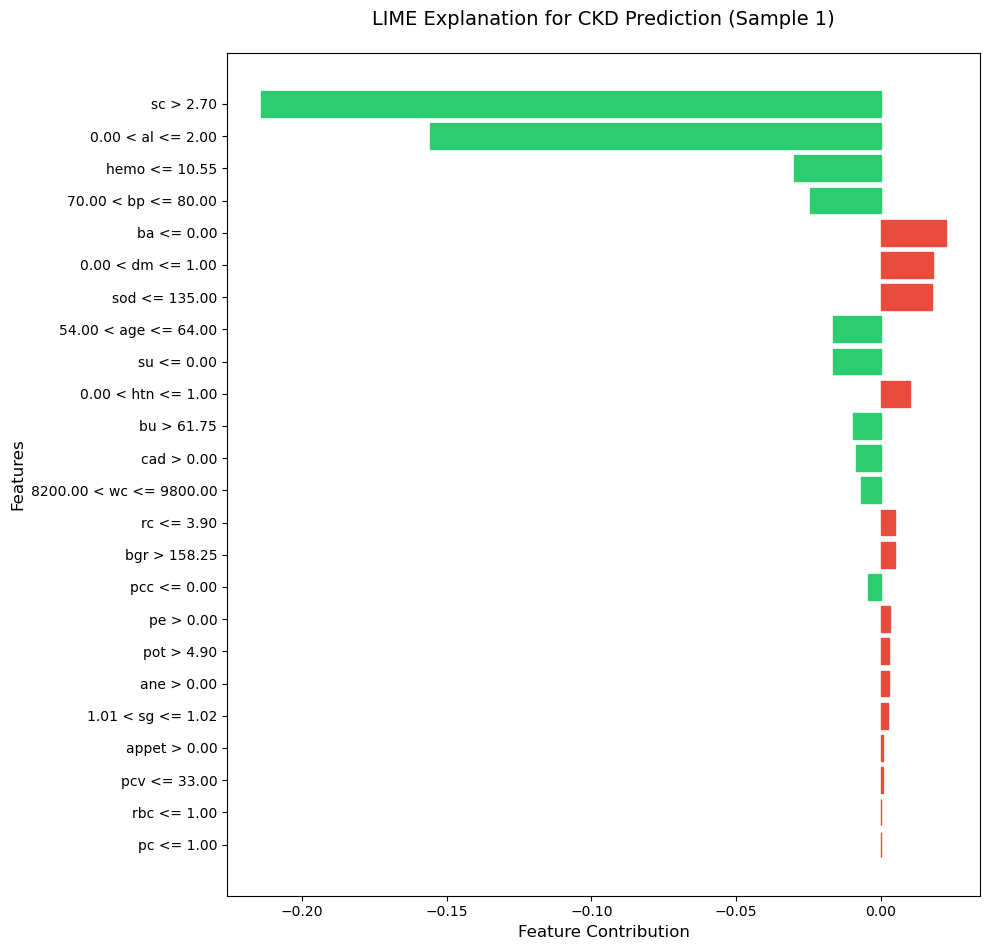

C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


LIME plot saved: lime_plots/lime_sample_2.png


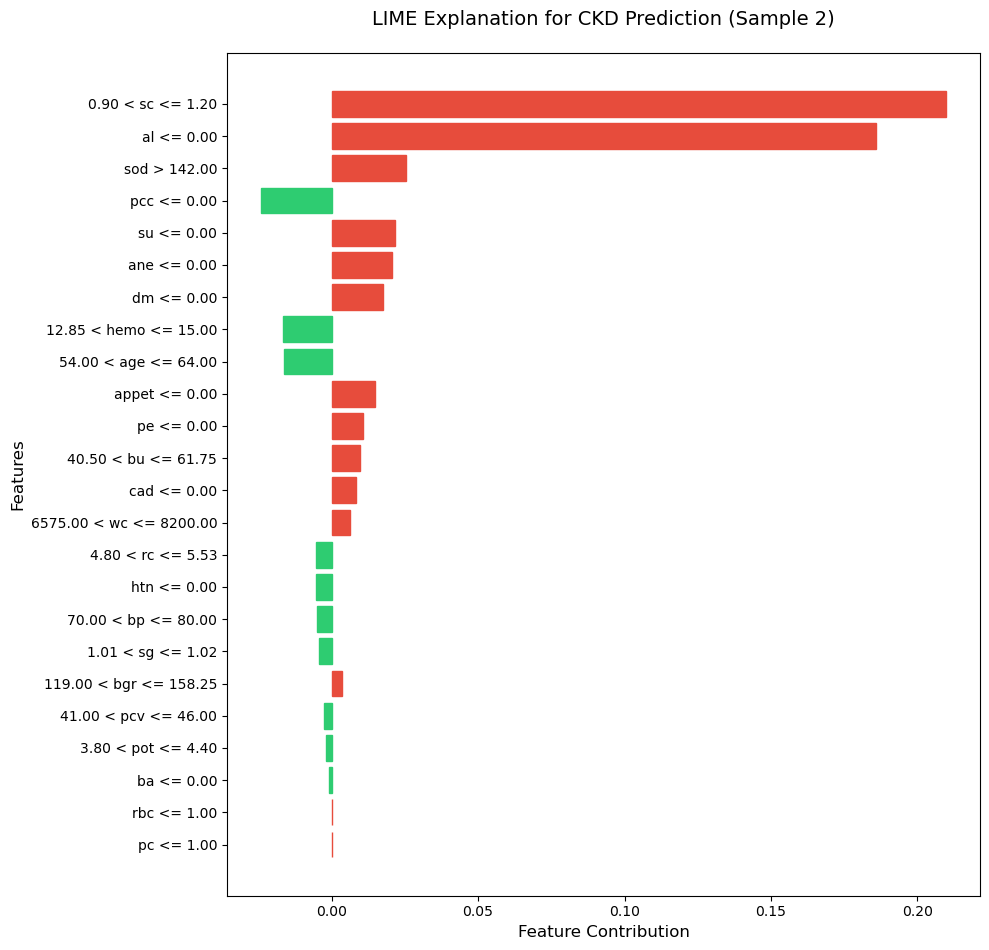

C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


LIME plot saved: lime_plots/lime_sample_3.png


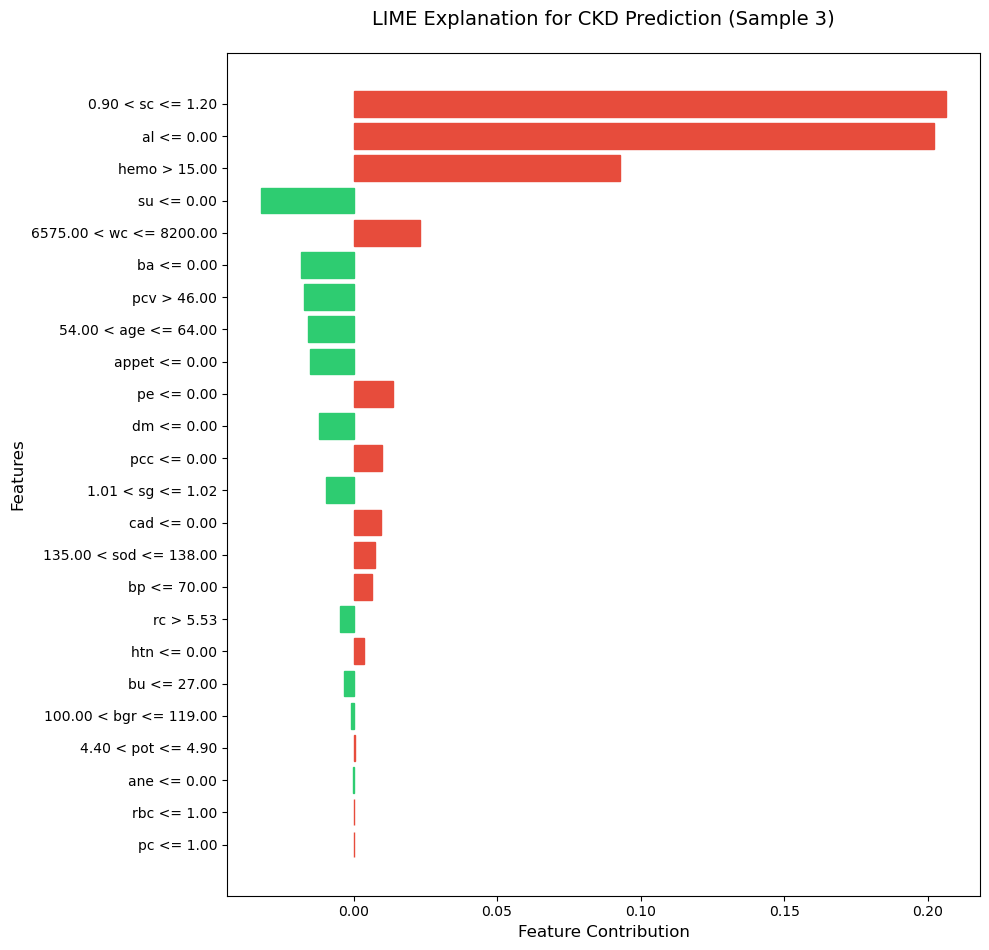

C:\Users\91824\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


LIME plot saved: lime_plots/lime_sample_4.png


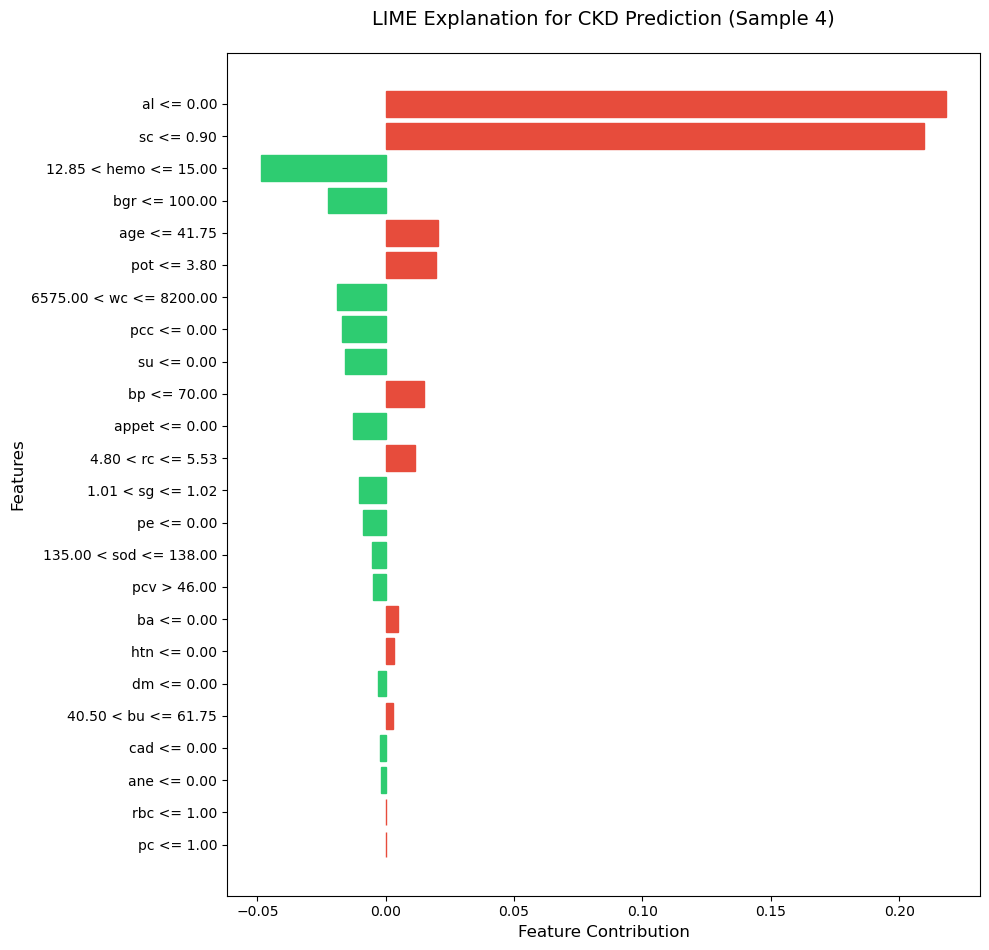

In [41]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import train_test_split

# === Load the trained Decision Tree model ===
with open('Decision_tree.pkl', 'rb') as f:
    dt = pickle.load(f)

# === Train-test split ===
X_df = X.copy()
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

# === LIME explainer setup ===
feature_names = X.columns.tolist()
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['Not CKD', 'CKD'],
    mode='classification',
    discretize_continuous=True
)

# === Create a folder for saving plots ===
os.makedirs("lime_plots", exist_ok=True)

# === Explain multiple test instances ===
for i in range(5):  # Loop through 3 samples (you can increase this)
    instance = X_test_df.iloc[i].values
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=dt.predict_proba,
        num_features=len(feature_names)
    )

    # === Plot LIME explanation ===
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation for CKD Prediction (Sample {i})", fontsize=14, pad=20)
    plt.xlabel("Feature Contribution", fontsize=12)
    plt.ylabel("Features", fontsize=12)

    # === Adjust bar colors (green = CKD, red = Not CKD) ===
    bars = plt.gca().patches
    for bar in bars:
        if bar.get_width() >= 0:
            bar.set_color('#e74c3c')  # Green
        else:
            bar.set_color('#2ecc71')  # Red 

    # === Layout improvements ===
    plt.tick_params(axis='y', labelsize=10)
    plt.tick_params(axis='x', labelsize=10)
    fig.set_size_inches(10, max(6, len(feature_names) * 0.4))
    plt.subplots_adjust(left=0.3)
    plt.tight_layout()

    # === Save the figure ===
    fig_path = f"lime_plots/lime_sample_{i}.png"
    plt.savefig(fig_path)
    print(f"LIME plot saved: {fig_path}")
    plt.show()


In [50]:
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Define LightGBM model
lgbm = LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Apply SMOTE to training data
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Fit the model
lgbm.fit(X_train_balanced, y_train_balanced)
y_pred = lgbm.predict(X_test)
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

[LightGBM] [Info] Number of positive: 200, number of negative: 200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 756
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

array([[50,  0],
       [ 2, 28]], dtype=int64)

In [51]:
import pickle
with open('lgbm_1.pkl', 'wb') as file:
    pickle.dump(lgbm, file)
print("Model saved successfully as 'lgbm_1.pkl'")

Model saved successfully as 'lgbm_1.pkl'
